In [23]:
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

In [24]:
# 1. Base Theme & Context
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# 2. Fine-grained RC Parameters
plt.rcParams.update({
    # Fonts & Sizes
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'figure.titlesize': 16,      # Suptitle size
    'axes.titlesize': 16,        # Ax title size (Standardized to 16)
    'axes.labelsize': 12,        # Ax label size

    # Weights (Bold globally)
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',

    # Structural Defaults
    'legend.frameon': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.axisbelow': True
})

In [25]:
def format_plot(ax, title, xlabel, ylabel, horizontal=False):
    """
    Applies structural formatting only.
    Styling (size/bold) is now handled automatically by rcParams.
    """
    # Just set the text. The Global Config handles size/bolding.
    ax.set_title(title, pad=20)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Grid Logic (Structural)
    # Note: We must explicitly turn OFF the opposing grid
    # because seaborn defaults might keep it on.
    if horizontal:
        ax.grid(axis='x', linestyle='--', alpha=0.5)
        ax.grid(axis='y', visible=False)
    else:
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.grid(axis='x', visible=False)

In [26]:
filePath = '../Dataset/UCI_Gallstone_Dataset.csv'
df = pd.read_csv(filePath)
df

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,1,49,0,0,0,0,0,0,178,88.8,...,55.0,81.0,28.0,50.0,90.0,0.98,94.50,6.2,16.5,8.3
315,1,31,1,0,0,0,0,0,157,53.4,...,58.0,64.0,24.0,16.0,38.0,0.50,128.50,0.0,12.5,24.0
316,1,58,0,0,0,0,0,0,172,96.6,...,45.0,168.0,21.0,27.0,94.0,1.04,83.23,0.0,15.4,15.7
317,1,37,1,0,0,0,0,0,177,88.4,...,33.0,253.0,40.0,22.0,115.0,1.01,98.23,0.4,16.0,33.3


In [27]:
df.isnull().values.any()

np.False_

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 39 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Gallstone Status                                319 non-null    int64  
 1   Age                                             319 non-null    int64  
 2   Gender                                          319 non-null    int64  
 3   Comorbidity                                     319 non-null    int64  
 4   Coronary Artery Disease (CAD)                   319 non-null    int64  
 5   Hypothyroidism                                  319 non-null    int64  
 6   Hyperlipidemia                                  319 non-null    int64  
 7   Diabetes Mellitus (DM)                          319 non-null    int64  
 8   Height                                          319 non-null    int64  
 9   Weight                                     

In [29]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Gallstone Status,319.0,0.495298,0.500763,0.00,0.000,0.000000,1.000,1.00
Age,319.0,48.068966,12.114558,20.00,38.500,49.000000,56.000,96.00
Gender,319.0,0.492163,0.500724,0.00,0.000,0.000000,1.000,1.00
Comorbidity,319.0,0.335423,0.517340,0.00,0.000,0.000000,1.000,3.00
Coronary Artery Disease (CAD),319.0,0.037618,0.190568,0.00,0.000,0.000000,0.000,1.00
Hypothyroidism,319.0,0.028213,0.165841,0.00,0.000,0.000000,0.000,1.00
Hyperlipidemia,319.0,0.025078,0.156609,0.00,0.000,0.000000,0.000,1.00
Diabetes Mellitus (DM),319.0,0.134796,0.342042,0.00,0.000,0.000000,0.000,1.00
Height,319.0,167.156740,10.053030,145.00,159.500,168.000000,175.000,191.00
Weight,319.0,80.564890,15.709069,42.90,69.600,78.800000,91.250,143.50


In [30]:
df['area/mass']= df['Visceral Muscle Area (VMA) (Kg)']/df['Muscle Mass (MM)']


In [31]:
dfBodyWater = df[['Total Body Water (TBW)','Extracellular Water (ECW)','Intracellular Water (ICW)','Extracellular Fluid/Total Body Water (ECF/TBW)']].copy()
dfBodyWater['Calculated (ECF/TBW)'] = (dfBodyWater['Extracellular Water (ECW)']/dfBodyWater['Total Body Water (TBW)']*100)
dfBodyWater['(ECF/TBW) Variance'] = dfBodyWater['Calculated (ECF/TBW)'] -df['Extracellular Fluid/Total Body Water (ECF/TBW)']
dfBodyWater['Total Body Water Variance'] = dfBodyWater['Total Body Water (TBW)'] - (df['Extracellular Water (ECW)'] + df['Intracellular Water (ICW)'])
dfBodyWater

,Total Body Water (TBW),Extracellular Water (ECW),Intracellular Water (ICW),Extracellular Fluid/Total Body Water (ECF/TBW),Calculated (ECF/TBW),(ECF/TBW) Variance,Total Body Water Variance
0,52.9,21.2,31.7,40.00,40.075614,0.075614,0.000000e+00
1,43.1,19.5,23.6,45.00,45.243619,0.243619,0.000000e+00
2,47.2,20.1,27.1,43.00,42.584746,-0.415254,0.000000e+00
3,41.4,17.0,24.4,41.00,41.062802,0.062802,0.000000e+00
4,51.4,20.0,31.4,39.00,38.910506,-0.089494,0.000000e+00
...,...,...,...,...,...,...,...
314,47.6,20.0,28.0,42.01,42.016807,0.006807,-4.000000e-01
315,29.3,12.3,17.0,42.00,41.979522,-0.020478,0.000000e+00
316,49.2,21.0,28.2,43.00,42.682927,-0.317073,0.000000e+00
317,50.2,19.9,30.3,40.00,39.641434,-0.358566,0.000000e+00


In [32]:
def cal_Obesity(BMI):
    return abs((BMI / 22 - 1) * 100)

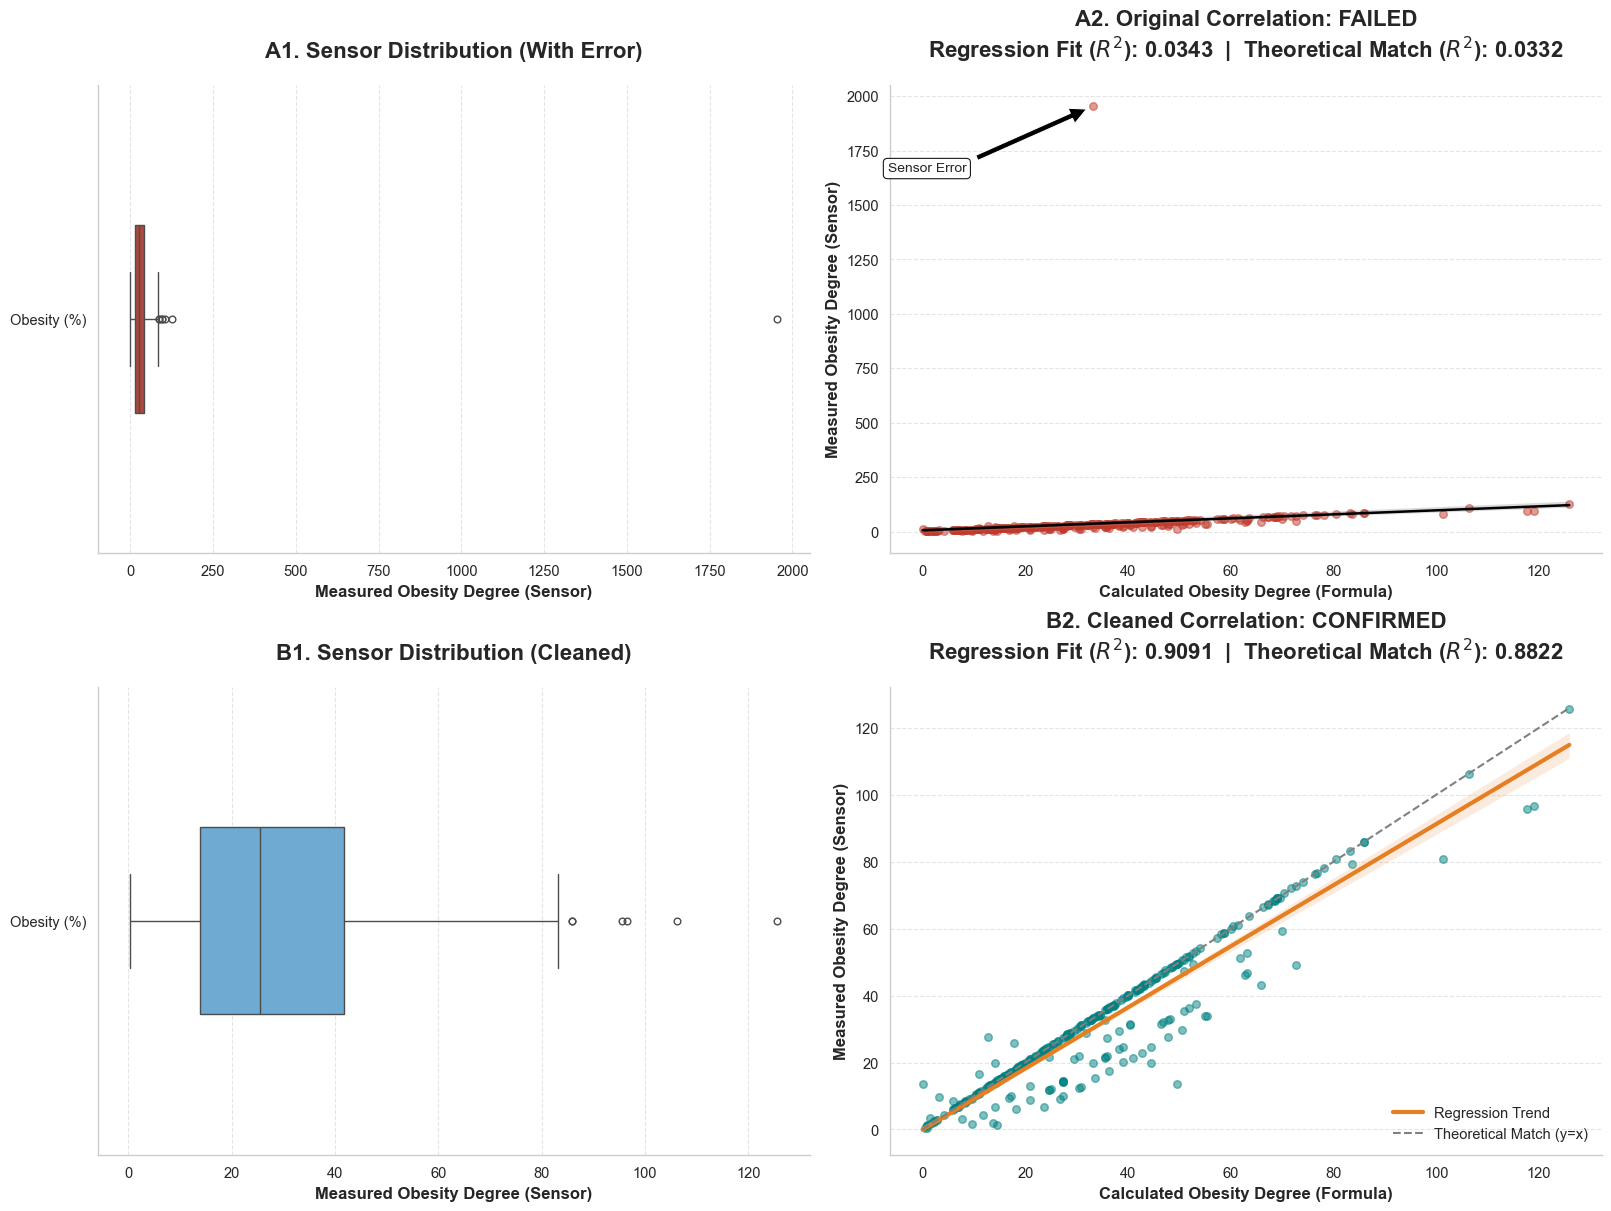

In [33]:
# 1. DATA PREP
df_orig = df.copy()
df_orig['Calculated_Obesity'] = df_orig['Body Mass Index (BMI)'].apply(cal_Obesity)
df_clean = df_orig[~np.isclose(df_orig['Obesity (%)'], 1954.00)].copy()

# --- METRIC 1: REGRESSION SCORE (Consistency) ---
# We square the Pearson R to get R^2 for the regression line
r_orig, _ = pearsonr(df_orig['Calculated_Obesity'], df_orig['Obesity (%)'])
r2_regr_orig = r_orig**2

r_clean, _ = pearsonr(df_clean['Calculated_Obesity'], df_clean['Obesity (%)'])
r2_regr_clean = r_clean**2

# --- METRIC 2: THEORETICAL SCORE (Accuracy) ---
# How well does it fit the PHYSICS FORMULA (y=x)?
def calc_theoretical_r2(df_input):
    # Order matters: (True, Pred) -> (Sensor, Formula)
    # This measures how well the formula predicts the sensor
    return r2_score(df_input['Obesity (%)'], df_input['Calculated_Obesity'])

r2_theory_orig = calc_theoretical_r2(df_orig)
r2_theory_clean = calc_theoretical_r2(df_clean)

# 2. VISUALIZATION
fig, axes = plt.subplots(2, 2, figsize=(16, 12), layout='constrained')

LABEL_Y_SENSOR = "Measured Obesity Degree (Sensor)"
LABEL_X_FORMULA = "Calculated Obesity Degree (Formula)"

# ==========================================
# ROW 1: SCENARIO A (Original)
# ==========================================
# 1A. Boxplot
sns.boxplot(data=df_orig[['Obesity (%)']], orient='h', ax=axes[0, 0], color='#C0392B', width=0.4)
format_plot(axes[0, 0], 'A1. Sensor Distribution (With Error)', LABEL_Y_SENSOR, '',True)

# 1B. Regression
sns.regplot(
    data=df_orig, x='Calculated_Obesity', y='Obesity (%)', ax=axes[0, 1],
    color='#C0392B', scatter_kws={'alpha': 0.5, 's': 30},
    line_kws={'color': 'black', 'label': 'Regression Trend'}
)
# Outlier Annotation
outlier_row = df_orig[np.isclose(df_orig['Obesity (%)'], 1954.00)]
if not outlier_row.empty:
    x_out, y_out = outlier_row['Calculated_Obesity'].values[0], outlier_row['Obesity (%)'].values[0]
    axes[0, 1].annotate("Sensor Error", xy=(x_out, y_out), xytext=(x_out-40, y_out-300),
                        arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10,
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.9))

# [CHANGE] Unified R² Metrics
title_a = (f"A2. Original Correlation: FAILED\n"
           f"Regression Fit ($R^2$): {r2_regr_orig:.4f}  |  Theoretical Match ($R^2$): {r2_theory_orig:.4f}")
format_plot(axes[0, 1], title_a, LABEL_X_FORMULA, LABEL_Y_SENSOR)


# ==========================================
# ROW 2: SCENARIO B (Cleaned)
# ==========================================
# 2A. Boxplot
sns.boxplot(data=df_clean[['Obesity (%)']], orient='h', ax=axes[1, 0], color='#5DADE2', width=0.4)
format_plot(axes[1, 0], 'B1. Sensor Distribution (Cleaned)', LABEL_Y_SENSOR, '',True)

# 2B. Regression
sns.regplot(
    data=df_clean, x='Calculated_Obesity', y='Obesity (%)', ax=axes[1, 1],
    color='teal', scatter_kws={'alpha': 0.5, 's': 30},
    line_kws={'color': '#E67E22', 'linewidth': 3, 'label': 'Regression Trend'}
)
limit = max(df_clean['Obesity (%)'].max(), df_clean['Calculated_Obesity'].max())
axes[1, 1].plot([0, limit], [0, limit], color='gray', linestyle='--', linewidth=1.5, label='Theoretical Match (y=x)')

# [CHANGE] Unified R² Metrics
title_b = (f"B2. Cleaned Correlation: CONFIRMED\n"
           f"Regression Fit ($R^2$): {r2_regr_clean:.4f}  |  Theoretical Match ($R^2$): {r2_theory_clean:.4f}")
format_plot(axes[1, 1], title_b, LABEL_X_FORMULA, LABEL_Y_SENSOR)

axes[1, 1].legend(loc='lower right')

plt.show()


